# Evaluación de Redes Neuronales para HAR – Dataset HARTH
**Universidad Católica Boliviana San Pablo – Introducción a Deep Learning**

Este notebook implementa el diseño experimental completo del perfil:
- Preprocesamiento del dataset HARTH
- Baseline SVM
- CNN 1D base
- CNN 1D + BiLSTM (modelo propuesto)
- CNN 1D + GRU (variante)
- Validación Leave-One-Subject-Out (LOSO)
- Visualización de resultados

**Requisito:** tener `harth.zip` en la misma carpeta que este notebook.

---
## CELDA 1 – Instalación de dependencias

In [ ]:
# Ejecutar solo la primera vez
!pip install torch numpy pandas scikit-learn matplotlib --quiet

---
## CELDA 2 – Imports y configuración global

In [ ]:
import zipfile, io, os, json, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix
)

warnings.filterwarnings('ignore')

# ── Configuración del experimento ──────────────────────────────
ZIP_PATH   = 'data\harth.zip'      # ← cambia si tu ZIP tiene otro nombre
FS         = 50               # Hz
WINDOW_SEC = 3                # segundos por ventana
OVERLAP    = 0.5              # 50% solapamiento
WINDOW_LEN = int(FS * WINDOW_SEC)            # 150 muestras
STEP       = int(WINDOW_LEN * (1 - OVERLAP)) # 75 muestras

# Hiperparámetros de entrenamiento
EPOCHS      = 50
BATCH_SIZE  = 128
LR          = 3e-4
PATIENCE    = 10
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

# 12 actividades originales de HARTH
ACTIVITY_LABELS = {
    1:  'walking',           2:  'running',
    3:  'shuffling',         4:  'stairs_up',
    5:  'stairs_down',       6:  'standing',
    7:  'sitting',           8:  'lying',
    13: 'cycling_sit',       14: 'cycling_stand',
    130:'cycling_sit_inact', 140:'cycling_st_inact',
}
LABEL_TO_IDX = {v: i for i, v in enumerate(ACTIVITY_LABELS.values())}
CODE_TO_IDX  = {k: LABEL_TO_IDX[v] for k, v in ACTIVITY_LABELS.items()}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}
N_CLASSES    = len(ACTIVITY_LABELS)
SENSOR_COLS  = ['back_x','back_y','back_z','thigh_x','thigh_y','thigh_z']

# Colores por modelo para gráficos
MODEL_COLORS = {
    'svm':       '#E15759',
    'cnn1d':     '#4E79A7',
    'cnn_bilstm':'#59A14F',
    'cnn_gru':   '#F28E2B',
}
MODEL_LABELS = {
    'svm':       'SVM (baseline)',
    'cnn1d':     'CNN 1D',
    'cnn_bilstm':'CNN + BiLSTM (propuesto)',
    'cnn_gru':   'CNN + GRU',
}

print(f'Dispositivo: {DEVICE}')
print(f'Ventana: {WINDOW_LEN} muestras ({WINDOW_SEC}s) | Paso: {STEP} muestras')
print(f'Clases: {N_CLASSES}')

Dispositivo: cpu
Ventana: 150 muestras (3s) | Paso: 75 muestras
Clases: 12


---
## CELDA 3 – Carga del dataset desde el ZIP

In [3]:
def load_harth_from_zip(zip_path):
    """
    Lee todos los CSV de sujetos desde el ZIP.
    Retorna dict {subject_id: DataFrame}.
    """
    subjects = {}
    with zipfile.ZipFile(zip_path, 'r') as zf:
        csv_files = sorted([f for f in zf.namelist() if f.endswith('.csv')])
        print(f'Archivos CSV en el ZIP: {len(csv_files)}')
        for fname in csv_files:
            subj_id = Path(fname).stem  # 'S006', 'S008', ...
            with zf.open(fname) as f:
                df = pd.read_csv(io.TextIOWrapper(f, encoding='utf-8'))
            df.columns = [c.strip().lower() for c in df.columns]
            df = df[df['label'].isin(CODE_TO_IDX.keys())].copy()
            df['label_idx'] = df['label'].map(CODE_TO_IDX)
            subjects[subj_id] = df
    return subjects

subjects = load_harth_from_zip(ZIP_PATH)

print(f'\nSujetos cargados: {len(subjects)}')
for sid, df in subjects.items():
    print(f'  {sid}: {len(df):>7,} filas | actividades: {sorted(df["label_idx"].unique())}')

Archivos CSV en el ZIP: 22

Sujetos cargados: 22
  S006: 408,709 filas | actividades: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  S008: 418,989 filas | actividades: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
  S009: 154,464 filas | actividades: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
  S010: 351,649 filas | actividades: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  S012: 382,414 filas | actividades: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  S013: 369,077 filas | actividades: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]
  S014: 366,487 filas | acti

---
## CELDA 4 – Análisis exploratorio (EDA)

Total muestras : 6,461,328  (35.90 horas a 50 Hz)
Total sujetos  : 22

Distribución de clases:
  [ 0] walking                 1,197,155  ( 18.5%)
  [ 1] running                  291,356  (  4.5%)
  [ 2] shuffling                254,839  (  3.9%)
  [ 3] stairs_up                 76,217  (  1.2%)
  [ 4] stairs_down               67,253  (  1.0%)
  [ 5] standing                 743,480  ( 11.5%)
  [ 6] sitting                 2,902,703  ( 44.9%)
  [ 7] lying                    428,898  (  6.6%)
  [ 8] cycling_sit              393,963  (  6.1%)
  [ 9] cycling_stand             55,814  (  0.9%)
  [10] cycling_sit_inact         41,785  (  0.6%)
  [11] cycling_st_inact           7,865  (  0.1%)


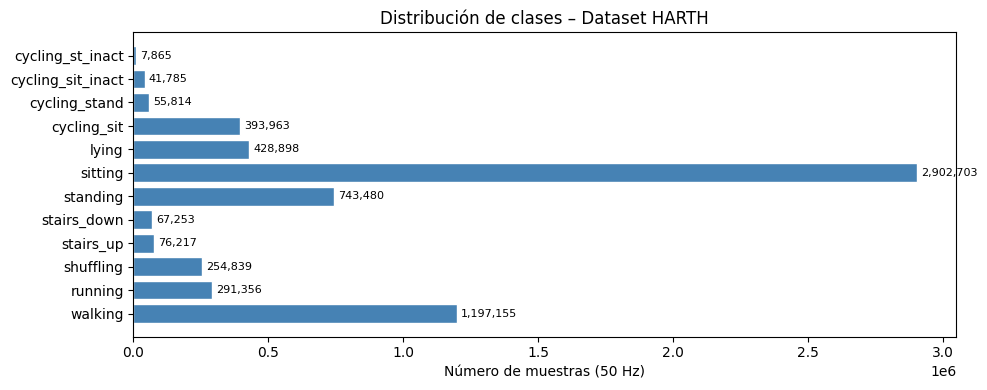

In [4]:
# Distribución global de clases
all_labels = []
for df in subjects.values():
    all_labels.extend(df['label_idx'].tolist())
counter = Counter(all_labels)
total   = len(all_labels)

print(f'Total muestras : {total:,}  ({total/FS/3600:.2f} horas a {FS} Hz)')
print(f'Total sujetos  : {len(subjects)}')
print('\nDistribución de clases:')
for idx in range(N_CLASSES):
    name  = IDX_TO_LABEL[idx]
    count = counter.get(idx, 0)
    print(f'  [{idx:2d}] {name:<22}  {count:>8,}  ({100*count/total:5.1f}%)')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
names  = [IDX_TO_LABEL[i] for i in range(N_CLASSES)]
counts = [counter.get(i, 0) for i in range(N_CLASSES)]
bars = ax.barh(names, counts, color='steelblue', edgecolor='white')
ax.set_xlabel('Número de muestras (50 Hz)')
ax.set_title('Distribución de clases – Dataset HARTH')
ax.bar_label(bars, labels=[f'{c:,}' for c in counts], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

---
## CELDA 5 – Visualización de señales de ejemplo

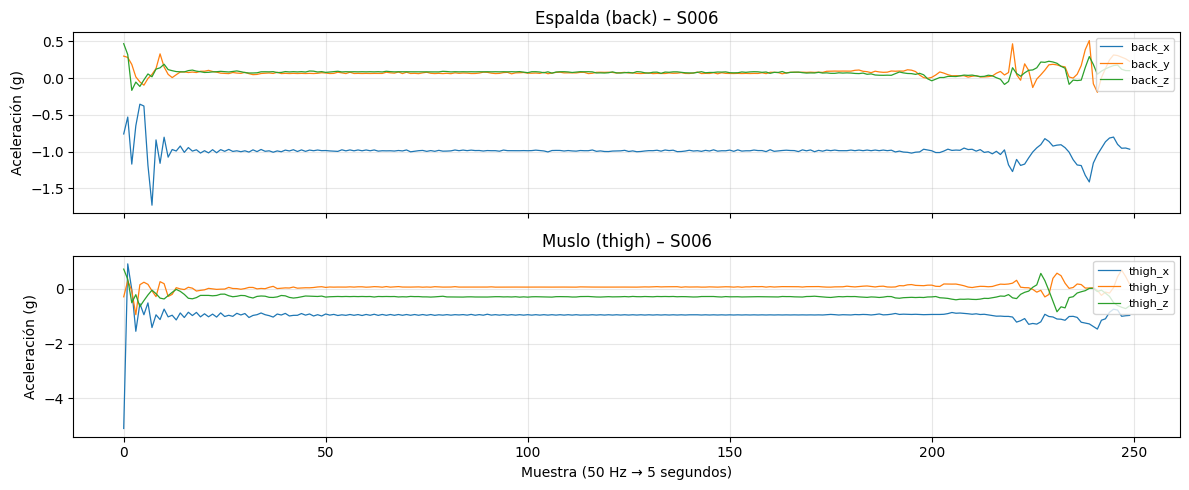

In [5]:
# Muestra 5 segundos de señal para el primer sujeto
sid_example = list(subjects.keys())[0]
df_ex = subjects[sid_example].iloc[:250]  # 5s a 50Hz

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

for i, (label, cols) in enumerate([
    ('Espalda (back)',  ['back_x',  'back_y',  'back_z']),
    ('Muslo (thigh)',   ['thigh_x', 'thigh_y', 'thigh_z']),
]):
    for col in cols:
        axes[i].plot(df_ex[col].values, label=col, linewidth=0.9)
    axes[i].set_ylabel('Aceleración (g)')
    axes[i].set_title(f'{label} – {sid_example}')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(alpha=0.3)

axes[1].set_xlabel('Muestra (50 Hz → 5 segundos)')
plt.tight_layout()
plt.show()

---
## CELDA 6 – Segmentación en ventanas deslizantes

In [6]:
def segment_subject(df):
    """Segmenta un sujeto en ventanas. Etiqueta = clase mayoritaria."""
    data   = df[SENSOR_COLS].values.astype(np.float32)
    labels = df['label_idx'].values
    X_list, y_list = [], []
    for start in range(0, len(data) - WINDOW_LEN + 1, STEP):
        end     = start + WINDOW_LEN
        window  = data[start:end]       # (150, 6)
        majority = Counter(labels[start:end]).most_common(1)[0][0]
        X_list.append(window)
        y_list.append(majority)
    if not X_list:
        return np.empty((0, WINDOW_LEN, 6), np.float32), np.empty((0,), np.int64)
    return np.array(X_list, np.float32), np.array(y_list, np.int64)

# Segmentar todos los sujetos
dataset = {}
total_windows = 0
for sid, df in subjects.items():
    X, y = segment_subject(df)
    dataset[sid] = (X, y)
    total_windows += len(X)
    print(f'  {sid}: {X.shape[0]:>5} ventanas | X={X.shape} | clases: {np.unique(y)}')

print(f'\nTotal ventanas: {total_windows:,}')
print(f'Forma de una ventana: {X.shape[1:]}  (muestras × canales)')

  S006:  5448 ventanas | X=(5448, 150, 6) | clases: [ 0  2  3  4  5  6  7  8  9 10]
  S008:  5585 ventanas | X=(5585, 150, 6) | clases: [ 0  2  3  4  5  6  8  9 10 11]
  S009:  2058 ventanas | X=(2058, 150, 6) | clases: [ 0  3  4  5  8  9 10 11]
  S010:  4687 ventanas | X=(4687, 150, 6) | clases: [0 2 3 4 5 6]
  S012:  5097 ventanas | X=(5097, 150, 6) | clases: [0 1 2 3 4 5 6 7]
  S013:  4920 ventanas | X=(4920, 150, 6) | clases: [ 0  1  2  3  4  5  6  7  8 10]
  S014:  4885 ventanas | X=(4885, 150, 6) | clases: [0 1 2 3 4 5 6 7 8]
  S015:  5577 ventanas | X=(5577, 150, 6) | clases: [0 1 2 3 4 5 6 7 8 9]
  S016:  4737 ventanas | X=(4737, 150, 6) | clases: [ 0  1  2  3  4  5  6  7  8  9 10]
  S017:  4887 ventanas | X=(4887, 150, 6) | clases: [ 0  1  2  3  4  5  6  7  8  9 10 11]
  S018:  4295 ventanas | X=(4295, 150, 6) | clases: [ 0  1  2  3  4  5  6  7  8  9 10]
  S019:  3971 ventanas | X=(3971, 150, 6) | clases: [ 0  1  2  3  4  5  6  7  8 10]
  S020:  4952 ventanas | X=(4952, 150, 6

---
## CELDA 7 – Normalización y pesos de clase

In [7]:
def normalize_fold(dataset, test_sid):
    """Media y std calculados SOLO en train, aplicados a train y test."""
    X_all = np.concatenate(
        [X for sid, (X, _) in dataset.items() if sid != test_sid], axis=0
    ).reshape(-1, 6)
    mean = X_all.mean(axis=0, keepdims=True)     # (1, 6)
    std  = X_all.std(axis=0,  keepdims=True) + 1e-8
    norm = {sid: ((X - mean) / std, y) for sid, (X, y) in dataset.items()}
    return norm, mean, std

def compute_class_weights(y_train):
    counts  = np.bincount(y_train, minlength=N_CLASSES).astype(np.float32)
    weights = y_train.shape[0] / (N_CLASSES * np.where(counts == 0, 1, counts))
    return torch.tensor(weights, dtype=torch.float32)

# Verificación rápida con el primer sujeto de prueba
_s0 = list(dataset.keys())[0]
_nd, _m, _s = normalize_fold(dataset, _s0)
print('Ejemplo normalización (primer fold):')
print(f'  mean por canal: {_m.flatten().round(4)}')
print(f'  std  por canal: {_s.flatten().round(4)}')

_yt = np.concatenate([y for sid, (_, y) in _nd.items() if sid != _s0])
cw  = compute_class_weights(_yt)
print(f'\nPesos de clase (entrenamiento sin {_s0}):')
for i, (w, name) in enumerate(zip(cw.tolist(), IDX_TO_LABEL.values())):
    print(f'  [{i:2d}] {name:<22}  {w:.3f}')

Ejemplo normalización (primer fold):
  mean por canal: [-0.9083 -0.0141 -0.1617 -0.6176  0.0125  0.3705]
  std  por canal: [0.3811 0.2308 0.3554 0.6267 0.3924 0.7393]

Pesos de clase (entrenamiento sin S006):
  [ 0] walking                 0.427
  [ 1] running                 1.729
  [ 2] shuffling               2.375
  [ 3] stairs_up               6.224
  [ 4] stairs_down             6.874
  [ 5] standing                0.737
  [ 6] sitting                 0.190
  [ 7] lying                   1.213
  [ 8] cycling_sit             1.365
  [ 9] cycling_stand           9.562
  [10] cycling_sit_inact       16.599
  [11] cycling_st_inact        64.639


---
## CELDA 8 – Features estadísticos para SVM

In [8]:
def extract_features(X):
    """
    Extrae features estadísticos de cada ventana para el SVM.
    X: (N, window_len, 6)  →  devuelve (N, n_features)
    """
    N, T, C = X.shape
    feats = []
    for i in range(N):
        win = X[i]  # (T, C)
        f = []
        for c in range(C):
            sig = win[:, c]
            f += [
                sig.mean(), sig.std(), sig.min(), sig.max(),
                sig.max() - sig.min(),
                float(np.median(sig)),
                float(np.percentile(sig, 25)),
                float(np.percentile(sig, 75)),
                float(np.sum(sig**2) / T),
                float(np.sqrt(np.mean(sig**2))),
                float(np.sum(np.diff(np.sign(sig)) != 0) / T),
                # autocorr lag-1: NaN si varianza=0 (señal constante), reemplazamos con 0
                float(np.corrcoef(sig[:-1], sig[1:])[0, 1]) if sig.std() > 1e-8 else 0.0,
            ]
        # Magnitud vectorial back y thigh
        for sl in [slice(0, 3), slice(3, 6)]:
            mag = np.sqrt((win[:, sl]**2).sum(axis=1))
            f += [mag.mean(), mag.std(), float(np.sqrt(np.mean(mag**2)))]
        # Correlación cruzada back–thigh por canal
        for c in range(3):
            s1, s2 = win[:, c], win[:, c+3]
            if s1.std() > 1e-8 and s2.std() > 1e-8:
                corr = float(np.corrcoef(s1, s2)[0, 1])
            else:
                corr = 0.0
            f.append(corr)
        feats.append(f)

    arr = np.array(feats, dtype=np.float32)
    # Limpieza defensiva: reemplazar cualquier NaN/Inf residual
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr

# Smoke-test
_X_s = dataset[_s0][0][:5]
_feat = extract_features(_X_s)
print(f'Features por ventana: {_feat.shape[1]}')
print(f'NaNs: {np.isnan(_feat).sum()} | Infs: {np.isinf(_feat).sum()}')
print(f'Ejemplo (primera ventana): {_feat[0][:10].round(4)} ...')

Features por ventana: 81
NaNs: 0 | Infs: 0
Ejemplo (primera ventana): [-0.9807  0.1117 -1.7302 -0.3551  1.3752 -0.9888 -0.9945 -0.9826  0.9742
  0.987 ] ...


---
## CELDA 9 – Definición de modelos de redes neuronales

In [9]:
# ─── Focal Loss ─────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


# ─── CNN 1D base ─────────────────────────────────────────────────
class CNN1D(nn.Module):
    """Red convolucional 1D. Entrada: (B, T, C)"""
    def __init__(self, n_ch=6, T=150, n_cls=12, drop=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_ch, 64,  7, padding=3), nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(64,  128, 5, padding=2), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, 3, padding=1), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(drop),
            nn.AdaptiveAvgPool1d(8),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(256*8, 256), nn.GELU(), nn.Dropout(drop), nn.Linear(256, n_cls)
        )
    def forward(self, x):
        return self.head(self.conv(x.permute(0, 2, 1)))


# ─── CNN 1D + BiLSTM con atención (modelo propuesto) ─────────────
class CNN1D_BiLSTM(nn.Module):
    def __init__(self, n_ch=6, T=150, n_cls=12, hid=128, layers=2, drop=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_ch, 64,  7, padding=3), nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(64,  128, 5, padding=2), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 3, padding=1), nn.BatchNorm1d(128), nn.GELU(),
        )
        self.rnn     = nn.LSTM(128, hid, layers, batch_first=True, bidirectional=True,
                               dropout=drop if layers > 1 else 0.0)
        self.attn_fc = nn.Linear(hid*2, 1)
        self.head    = nn.Sequential(nn.Linear(hid*2, 256), nn.GELU(), nn.Dropout(drop), nn.Linear(256, n_cls))

    def forward(self, x):
        x = self.cnn(x.permute(0,2,1)).permute(0,2,1)
        out, _ = self.rnn(x)
        ctx = (torch.softmax(self.attn_fc(out), dim=1) * out).sum(dim=1)
        return self.head(ctx)


# ─── CNN 1D + GRU con atención (variante) ────────────────────────
class CNN1D_GRU(nn.Module):
    def __init__(self, n_ch=6, T=150, n_cls=12, hid=128, layers=2, drop=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_ch, 64,  7, padding=3), nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(64,  128, 5, padding=2), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(drop), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 3, padding=1), nn.BatchNorm1d(128), nn.GELU(),
        )
        self.rnn     = nn.GRU(128, hid, layers, batch_first=True, bidirectional=True,
                              dropout=drop if layers > 1 else 0.0)
        self.attn_fc = nn.Linear(hid*2, 1)
        self.head    = nn.Sequential(nn.Linear(hid*2, 256), nn.GELU(), nn.Dropout(drop), nn.Linear(256, n_cls))

    def forward(self, x):
        x = self.cnn(x.permute(0,2,1)).permute(0,2,1)
        out, _ = self.rnn(x)
        ctx = (torch.softmax(self.attn_fc(out), dim=1) * out).sum(dim=1)
        return self.head(ctx)


# ─── Smoke-test de dimensiones ───────────────────────────────────
x_test = torch.randn(4, WINDOW_LEN, 6)
for name, cls in [('CNN1D', CNN1D), ('CNN1D_BiLSTM', CNN1D_BiLSTM), ('CNN1D_GRU', CNN1D_GRU)]:
    m = cls()
    out = m(x_test)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name:<16}  salida={tuple(out.shape)}  parámetros={params:,}')

CNN1D             salida=(4, 12)  parámetros=670,924
CNN1D_BiLSTM      salida=(4, 12)  parámetros=822,349
CNN1D_GRU         salida=(4, 12)  parámetros=657,485


---
## CELDA 10 – Función de entrenamiento de una red (1 fold LOSO)

In [10]:
def train_neural_fold(ModelClass, dataset, test_sid, verbose=True):
    """
    Entrena ModelClass en todos los sujetos excepto test_sid,
    evalúa en test_sid. Retorna (y_true, y_pred, historial_loss).
    """
    norm_ds, _, _ = normalize_fold(dataset, test_sid)

    X_test, y_test = norm_ds[test_sid]
    X_tr = np.concatenate([X for s,(X,_) in norm_ds.items() if s != test_sid])
    y_tr = np.concatenate([y for s,(_,y) in norm_ds.items() if s != test_sid])

    cw = compute_class_weights(y_tr).to(DEVICE)

    tr_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=True
    )
    te_loader = DataLoader(
        TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long)),
        batch_size=BATCH_SIZE*4
    )

    model     = ModelClass().to(DEVICE)
    criterion = FocalLoss(gamma=2.0, weight=cw)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_f1, patience_cnt, best_state = 0.0, 0, None
    loss_history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        ep_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        scheduler.step()
        avg_loss = ep_loss / len(tr_loader)
        loss_history.append(avg_loss)

        if epoch % 5 == 0:
            model.eval()
            preds = []
            with torch.no_grad():
                for Xb, _ in te_loader:
                    preds.append(model(Xb.to(DEVICE)).argmax(1).cpu())
            val_f1 = f1_score(y_test, torch.cat(preds).numpy(),
                              average='macro', zero_division=0)
            if val_f1 > best_f1:
                best_f1     = val_f1
                patience_cnt = 0
                best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                patience_cnt += 1
                if patience_cnt >= PATIENCE // 5:
                    if verbose:
                        print(f'      Early stop epoch={epoch} best_f1={best_f1:.4f}')
                    break
            if verbose and epoch % 10 == 0:
                print(f'      epoch {epoch:3d}  loss={avg_loss:.4f}  val_f1={val_f1:.4f}')

    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    preds = []
    with torch.no_grad():
        for Xb, _ in te_loader:
            preds.append(model(Xb.to(DEVICE)).argmax(1).cpu())
    return y_test, torch.cat(preds).numpy(), loss_history


def train_svm_fold(dataset, test_sid):
    norm_ds, _, _ = normalize_fold(dataset, test_sid)
    X_test, y_test = norm_ds[test_sid]
    X_tr = np.concatenate([X for s,(X,_) in norm_ds.items() if s != test_sid])
    y_tr = np.concatenate([y for s,(_,y) in norm_ds.items() if s != test_sid])
    print(f'      Extrayendo features...')
    Xf_tr = extract_features(X_tr)
    Xf_te = extract_features(X_test)
    svm = Pipeline([('sc', StandardScaler()),
                    ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                               class_weight='balanced', random_state=42))])
    print(f'      Entrenando SVM ({Xf_tr.shape[0]:,} ventanas, {Xf_tr.shape[1]} features)...')
    svm.fit(Xf_tr, y_tr)
    return y_test, svm.predict(Xf_te)


def compute_metrics(y_true, y_pred):
    return {
        'accuracy':    float(accuracy_score(y_true, y_pred)),
        'f1_macro':    float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'f1_weighted': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'precision':   float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall':      float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_per_class':f1_score(y_true, y_pred, average=None,
                                labels=list(range(N_CLASSES)), zero_division=0).tolist(),
        'conf_matrix': confusion_matrix(y_true, y_pred,
                                        labels=list(range(N_CLASSES))).tolist(),
    }

print('✅ Funciones de entrenamiento definidas.')

✅ Funciones de entrenamiento definidas.


---
## CELDA 11 – Entrenamiento LOSO: SVM (baseline)
> ⏱️ Tiempo estimado: 10–20 min dependiendo de la CPU

In [11]:
subjects_list = list(dataset.keys())
results_svm   = {'per_subject': [], 'y_true_all': [], 'y_pred_all': []}

for i, test_sid in enumerate(subjects_list, 1):
    t0 = time.time()
    print(f'[{i:2d}/{len(subjects_list)}] Test sujeto: {test_sid}')
    y_true, y_pred = train_svm_fold(dataset, test_sid)
    m = compute_metrics(y_true, y_pred)
    m['subject'] = test_sid
    m['time_s']  = round(time.time() - t0, 1)
    results_svm['per_subject'].append(m)
    results_svm['y_true_all'].extend(y_true.tolist())
    results_svm['y_pred_all'].extend(y_pred.tolist())
    print(f'      ✓  F1-macro={m["f1_macro"]:.4f}  Acc={m["accuracy"]:.4f}  ({m["time_s"]}s)\n')

results_svm['mean_f1_macro']  = float(np.mean([r['f1_macro']  for r in results_svm['per_subject']]))
results_svm['std_f1_macro']   = float(np.std( [r['f1_macro']  for r in results_svm['per_subject']]))
results_svm['mean_accuracy']  = float(np.mean([r['accuracy']  for r in results_svm['per_subject']]))
results_svm['mean_precision'] = float(np.mean([r['precision'] for r in results_svm['per_subject']]))
results_svm['mean_recall']    = float(np.mean([r['recall']    for r in results_svm['per_subject']]))
results_svm['global_metrics'] = compute_metrics(
    np.array(results_svm['y_true_all']),
    np.array(results_svm['y_pred_all'])
)

print('\n' + '='*50)
print('SVM – RESULTADOS FINALES')
print(f"  F1-macro : {results_svm['mean_f1_macro']:.4f} ± {results_svm['std_f1_macro']:.4f}")
print(f"  Accuracy : {results_svm['mean_accuracy']:.4f}")
print(f"  Precision: {results_svm['mean_precision']:.4f}")
print(f"  Recall   : {results_svm['mean_recall']:.4f}")

[ 1/22] Test sujeto: S006
      Extrayendo features...
      Entrenando SVM (80,669 ventanas, 81 features)...
      ✓  F1-macro=0.5388  Acc=0.8878  (83.5s)

[ 2/22] Test sujeto: S008
      Extrayendo features...
      Entrenando SVM (80,532 ventanas, 81 features)...
      ✓  F1-macro=0.4597  Acc=0.9336  (83.8s)

[ 3/22] Test sujeto: S009
      Extrayendo features...
      Entrenando SVM (84,059 ventanas, 81 features)...
      ✓  F1-macro=0.2790  Acc=0.4456  (87.0s)

[ 4/22] Test sujeto: S010
      Extrayendo features...
      Entrenando SVM (81,430 ventanas, 81 features)...
      ✓  F1-macro=0.6005  Acc=0.7845  (84.4s)

[ 5/22] Test sujeto: S012
      Extrayendo features...
      Entrenando SVM (81,020 ventanas, 81 features)...
      ✓  F1-macro=0.8723  Acc=0.9710  (85.3s)

[ 6/22] Test sujeto: S013
      Extrayendo features...
      Entrenando SVM (81,197 ventanas, 81 features)...
      ✓  F1-macro=0.6804  Acc=0.8957  (83.6s)

[ 7/22] Test sujeto: S014
      Extrayendo features...
   

---
## CELDA 12 – Entrenamiento LOSO: CNN 1D
> ⏱️ Tiempo estimado: 15–40 min (CPU) / 5–10 min (GPU)

In [12]:
results_cnn   = {'per_subject': [], 'y_true_all': [], 'y_pred_all': []}

for i, test_sid in enumerate(subjects_list, 1):
    t0 = time.time()
    print(f'[{i:2d}/{len(subjects_list)}] Test sujeto: {test_sid}')
    y_true, y_pred, _ = train_neural_fold(CNN1D, dataset, test_sid, verbose=True)
    m = compute_metrics(y_true, y_pred)
    m['subject'] = test_sid
    m['time_s']  = round(time.time() - t0, 1)
    results_cnn['per_subject'].append(m)
    results_cnn['y_true_all'].extend(y_true.tolist())
    results_cnn['y_pred_all'].extend(y_pred.tolist())
    print(f'      ✓  F1-macro={m["f1_macro"]:.4f}  Acc={m["accuracy"]:.4f}  ({m["time_s"]}s)\n')

results_cnn['mean_f1_macro']  = float(np.mean([r['f1_macro']  for r in results_cnn['per_subject']]))
results_cnn['std_f1_macro']   = float(np.std( [r['f1_macro']  for r in results_cnn['per_subject']]))
results_cnn['mean_accuracy']  = float(np.mean([r['accuracy']  for r in results_cnn['per_subject']]))
results_cnn['mean_precision'] = float(np.mean([r['precision'] for r in results_cnn['per_subject']]))
results_cnn['mean_recall']    = float(np.mean([r['recall']    for r in results_cnn['per_subject']]))
results_cnn['global_metrics'] = compute_metrics(
    np.array(results_cnn['y_true_all']),
    np.array(results_cnn['y_pred_all'])
)

print('\n' + '='*50)
print('CNN 1D – RESULTADOS FINALES')
print(f"  F1-macro : {results_cnn['mean_f1_macro']:.4f} ± {results_cnn['std_f1_macro']:.4f}")
print(f"  Accuracy : {results_cnn['mean_accuracy']:.4f}")

[ 1/22] Test sujeto: S006
      epoch  10  loss=0.1648  val_f1=0.5938
      Early stop epoch=20 best_f1=0.5938
      ✓  F1-macro=0.5938  Acc=0.8555  (1407.7s)

[ 2/22] Test sujeto: S008
      epoch  10  loss=0.1710  val_f1=0.2740
      epoch  20  loss=0.0935  val_f1=0.4186
      epoch  30  loss=0.0552  val_f1=0.4092
      epoch  40  loss=0.0321  val_f1=0.4426
      epoch  50  loss=0.0309  val_f1=0.4471
      ✓  F1-macro=0.4581  Acc=0.8387  (3504.4s)

[ 3/22] Test sujeto: S009
      epoch  10  loss=0.1892  val_f1=0.4415
      Early stop epoch=15 best_f1=0.4525
      ✓  F1-macro=0.4525  Acc=0.8523  (1089.4s)

[ 4/22] Test sujeto: S010
      epoch  10  loss=0.1898  val_f1=0.5500
      epoch  20  loss=0.0945  val_f1=0.5372
      epoch  30  loss=0.0563  val_f1=0.7113
      Early stop epoch=40 best_f1=0.7113
      ✓  F1-macro=0.7113  Acc=0.8044  (2826.9s)

[ 5/22] Test sujeto: S012
      epoch  10  loss=0.1654  val_f1=0.6309
      Early stop epoch=20 best_f1=0.6309
      ✓  F1-macro=0.6309  

---
## CELDA 13 – Entrenamiento LOSO: CNN + BiLSTM (modelo propuesto)
> ⏱️ Tiempo estimado: 20–50 min (CPU) / 8–15 min (GPU)

In [13]:
results_bilstm = {'per_subject': [], 'y_true_all': [], 'y_pred_all': []}

for i, test_sid in enumerate(subjects_list, 1):
    t0 = time.time()
    print(f'[{i:2d}/{len(subjects_list)}] Test sujeto: {test_sid}')
    y_true, y_pred, _ = train_neural_fold(CNN1D_BiLSTM, dataset, test_sid, verbose=True)
    m = compute_metrics(y_true, y_pred)
    m['subject'] = test_sid
    m['time_s']  = round(time.time() - t0, 1)
    results_bilstm['per_subject'].append(m)
    results_bilstm['y_true_all'].extend(y_true.tolist())
    results_bilstm['y_pred_all'].extend(y_pred.tolist())
    print(f'      ✓  F1-macro={m["f1_macro"]:.4f}  Acc={m["accuracy"]:.4f}  ({m["time_s"]}s)\n')

results_bilstm['mean_f1_macro']  = float(np.mean([r['f1_macro']  for r in results_bilstm['per_subject']]))
results_bilstm['std_f1_macro']   = float(np.std( [r['f1_macro']  for r in results_bilstm['per_subject']]))
results_bilstm['mean_accuracy']  = float(np.mean([r['accuracy']  for r in results_bilstm['per_subject']]))
results_bilstm['mean_precision'] = float(np.mean([r['precision'] for r in results_bilstm['per_subject']]))
results_bilstm['mean_recall']    = float(np.mean([r['recall']    for r in results_bilstm['per_subject']]))
results_bilstm['global_metrics'] = compute_metrics(
    np.array(results_bilstm['y_true_all']),
    np.array(results_bilstm['y_pred_all'])
)

print('\n' + '='*50)
print('CNN + BiLSTM – RESULTADOS FINALES')
print(f"  F1-macro : {results_bilstm['mean_f1_macro']:.4f} ± {results_bilstm['std_f1_macro']:.4f}")
print(f"  Accuracy : {results_bilstm['mean_accuracy']:.4f}")

[ 1/22] Test sujeto: S006
      epoch  10  loss=0.1850  val_f1=0.6376
      Early stop epoch=20 best_f1=0.6376
      ✓  F1-macro=0.6376  Acc=0.8743  (1849.9s)

[ 2/22] Test sujeto: S008
      epoch  10  loss=0.2006  val_f1=0.4168
      Early stop epoch=15 best_f1=0.4334
      ✓  F1-macro=0.4334  Acc=0.8435  (1384.8s)

[ 3/22] Test sujeto: S009
      epoch  10  loss=0.2506  val_f1=0.3842
      Early stop epoch=20 best_f1=0.3842
      ✓  F1-macro=0.3842  Acc=0.7930  (1913.9s)

[ 4/22] Test sujeto: S010
      epoch  10  loss=0.2306  val_f1=0.7163
      epoch  20  loss=0.1280  val_f1=0.7682
      Early stop epoch=30 best_f1=0.7682
      ✓  F1-macro=0.7682  Acc=0.7843  (2773.0s)

[ 5/22] Test sujeto: S012
      epoch  10  loss=0.2210  val_f1=0.5147
      epoch  20  loss=0.1232  val_f1=0.4877
      epoch  30  loss=0.0777  val_f1=0.5765
      epoch  40  loss=0.0459  val_f1=0.5972
      epoch  50  loss=0.0342  val_f1=0.6054
      ✓  F1-macro=0.6054  Acc=0.8944  (4755.8s)

[ 6/22] Test sujeto: 

---
## CELDA 14 – Entrenamiento LOSO: CNN + GRU (variante)
> ⏱️ Tiempo estimado: 15–40 min (CPU) / 6–12 min (GPU)

In [14]:
results_gru = {'per_subject': [], 'y_true_all': [], 'y_pred_all': []}

for i, test_sid in enumerate(subjects_list, 1):
    t0 = time.time()
    print(f'[{i:2d}/{len(subjects_list)}] Test sujeto: {test_sid}')
    y_true, y_pred, _ = train_neural_fold(CNN1D_GRU, dataset, test_sid, verbose=True)
    m = compute_metrics(y_true, y_pred)
    m['subject'] = test_sid
    m['time_s']  = round(time.time() - t0, 1)
    results_gru['per_subject'].append(m)
    results_gru['y_true_all'].extend(y_true.tolist())
    results_gru['y_pred_all'].extend(y_pred.tolist())
    print(f'      ✓  F1-macro={m["f1_macro"]:.4f}  Acc={m["accuracy"]:.4f}  ({m["time_s"]}s)\n')

results_gru['mean_f1_macro']  = float(np.mean([r['f1_macro']  for r in results_gru['per_subject']]))
results_gru['std_f1_macro']   = float(np.std( [r['f1_macro']  for r in results_gru['per_subject']]))
results_gru['mean_accuracy']  = float(np.mean([r['accuracy']  for r in results_gru['per_subject']]))
results_gru['mean_precision'] = float(np.mean([r['precision'] for r in results_gru['per_subject']]))
results_gru['mean_recall']    = float(np.mean([r['recall']    for r in results_gru['per_subject']]))
results_gru['global_metrics'] = compute_metrics(
    np.array(results_gru['y_true_all']),
    np.array(results_gru['y_pred_all'])
)

print('\n' + '='*50)
print('CNN + GRU – RESULTADOS FINALES')
print(f"  F1-macro : {results_gru['mean_f1_macro']:.4f} ± {results_gru['std_f1_macro']:.4f}")
print(f"  Accuracy : {results_gru['mean_accuracy']:.4f}")

[ 1/22] Test sujeto: S006
      epoch  10  loss=0.1998  val_f1=0.6828
      epoch  20  loss=0.1064  val_f1=0.6635
      Early stop epoch=25 best_f1=0.6842
      ✓  F1-macro=0.6842  Acc=0.8856  (2097.1s)

[ 2/22] Test sujeto: S008
      epoch  10  loss=0.2131  val_f1=0.4690
      Early stop epoch=20 best_f1=0.4690
      ✓  F1-macro=0.4690  Acc=0.8972  (1683.4s)

[ 3/22] Test sujeto: S009
      epoch  10  loss=0.2425  val_f1=0.4115
      epoch  20  loss=0.1398  val_f1=0.5167
      epoch  30  loss=0.0831  val_f1=0.5810
      Early stop epoch=40 best_f1=0.5810
      ✓  F1-macro=0.5810  Acc=0.8644  (3481.1s)

[ 4/22] Test sujeto: S010
      epoch  10  loss=0.2201  val_f1=0.6920
      Early stop epoch=20 best_f1=0.6920
      ✓  F1-macro=0.6920  Acc=0.7839  (1693.3s)

[ 5/22] Test sujeto: S012
      epoch  10  loss=0.2131  val_f1=0.5749
      epoch  20  loss=0.1225  val_f1=0.5954
      Early stop epoch=25 best_f1=0.6241
      ✓  F1-macro=0.6241  Acc=0.9478  (2106.3s)

[ 6/22] Test sujeto: S01

---
## CELDA 15 – Tabla comparativa de resultados

In [15]:
HARTH_PAPER = {'f1_macro': 0.81, 'precision': 0.79, 'recall': 0.85}

all_results = {
    'svm':       results_svm,
    'cnn1d':     results_cnn,
    'cnn_bilstm':results_bilstm,
    'cnn_gru':   results_gru,
}

rows = []
for key, res in all_results.items():
    rows.append({
        'Modelo':     MODEL_LABELS[key],
        'F1-macro':   f"{res['mean_f1_macro']:.4f} ± {res['std_f1_macro']:.4f}",
        'Accuracy':   f"{res['mean_accuracy']:.4f}",
        'Precision':  f"{res['mean_precision']:.4f}",
        'Recall':     f"{res['mean_recall']:.4f}",
        'vs paper':   f"{res['mean_f1_macro'] - HARTH_PAPER['f1_macro']:+.4f}",
    })
rows.append({
    'Modelo':    '── SVM paper original [Logacjov 2021] ──',
    'F1-macro':  f"{HARTH_PAPER['f1_macro']:.4f} (reportado)",
    'Accuracy':  '—',
    'Precision': f"{HARTH_PAPER['precision']:.4f}",
    'Recall':    f"{HARTH_PAPER['recall']:.4f}",
    'vs paper':  '0.0000',
})

df_results = pd.DataFrame(rows)
print('\nCOMPARACIÓN DE MODELOS – HARTH LOSO (12 clases)')
print('=' * 90)
print(df_results.to_string(index=False))
print('=' * 90)

df_results.to_csv('comparison_table.csv', index=False)
print('\nTabla guardada en comparison_table.csv')


COMPARACIÓN DE MODELOS – HARTH LOSO (12 clases)
                                  Modelo           F1-macro Accuracy Precision Recall vs paper
                          SVM (baseline)    0.6709 ± 0.1349   0.8861    0.6854 0.7149  -0.1391
                                  CNN 1D    0.6454 ± 0.0995   0.8509    0.6912 0.7001  -0.1646
                CNN + BiLSTM (propuesto)    0.6366 ± 0.1215   0.8239    0.6885 0.6967  -0.1734
                               CNN + GRU    0.6585 ± 0.1023   0.8605    0.6832 0.7139  -0.1515
── SVM paper original [Logacjov 2021] ── 0.8100 (reportado)        —    0.7900 0.8500   0.0000

Tabla guardada en comparison_table.csv


---
## CELDA 16 – Boxplot F1-macro por sujeto

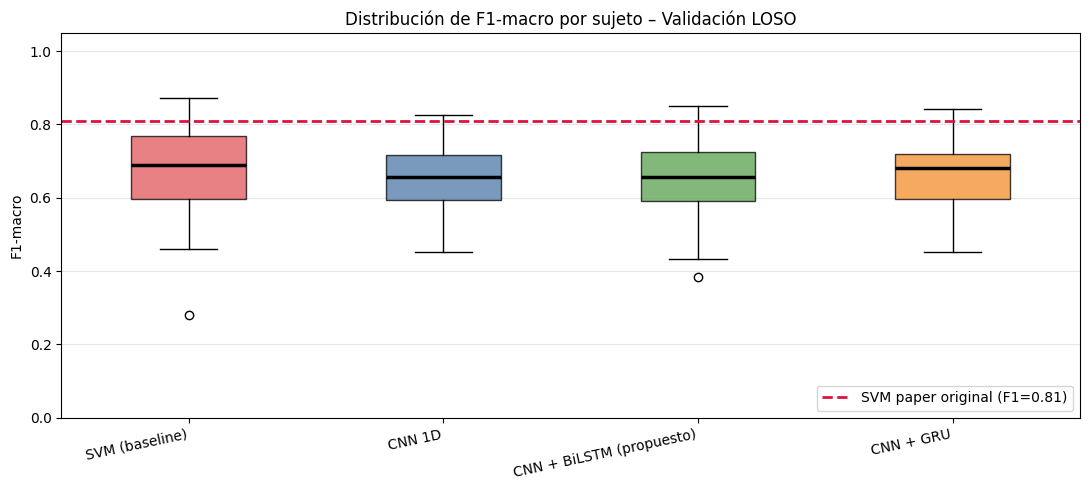

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

data_box, labels_box, colors_box = [], [], []
for key, res in all_results.items():
    data_box.append([r['f1_macro'] for r in res['per_subject']])
    labels_box.append(MODEL_LABELS[key])
    colors_box.append(MODEL_COLORS[key])

bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(HARTH_PAPER['f1_macro'], color='crimson', linestyle='--',
           linewidth=2, label=f"SVM paper original (F1={HARTH_PAPER['f1_macro']})")

ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels_box, rotation=12, ha='right')
ax.set_ylabel('F1-macro')
ax.set_ylim(0, 1.05)
ax.set_title('Distribución de F1-macro por sujeto – Validación LOSO')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('f1_boxplot.png', dpi=150)
plt.show()

---
## CELDA 17 – Matriz de confusión del mejor modelo

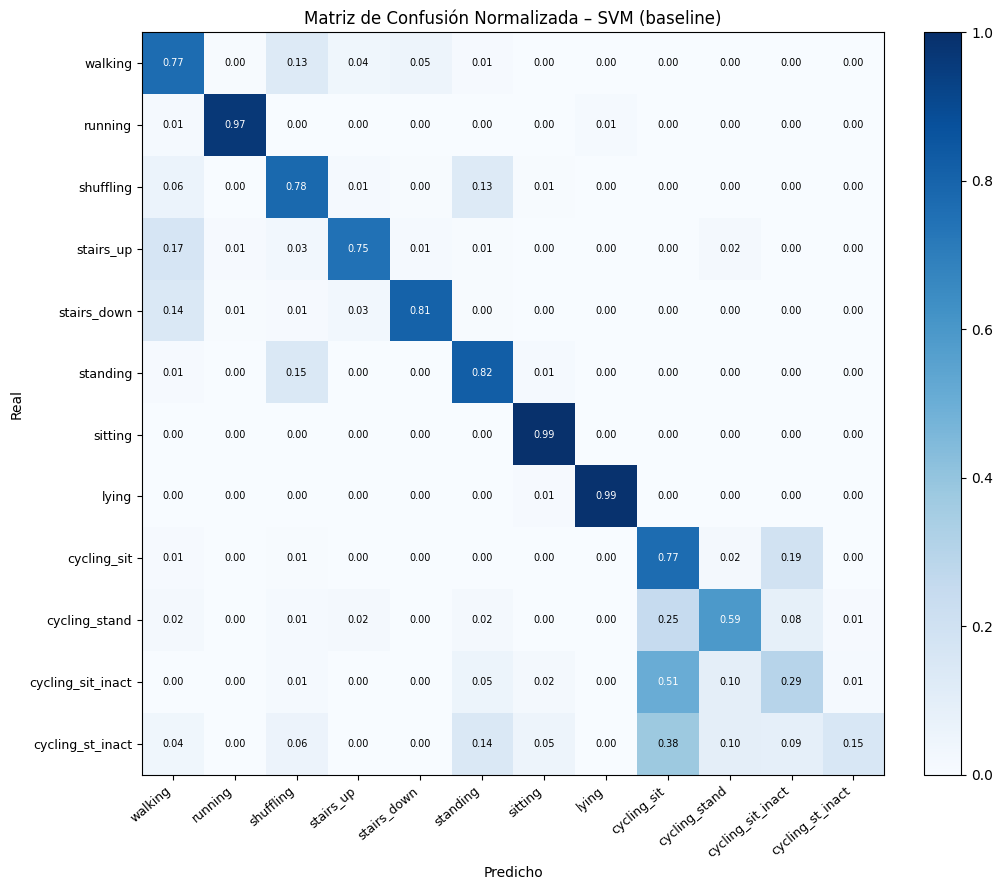

Mejor modelo: SVM (baseline)


In [17]:
best_key = max(all_results, key=lambda k: all_results[k]['mean_f1_macro'])
cm = np.array(all_results[best_key]['global_metrics']['conf_matrix'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
class_names = [IDX_TO_LABEL[i] for i in range(N_CLASSES)]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(class_names, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(class_names, fontsize=9)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        color = 'white' if cm_norm[i,j] > 0.5 else 'black'
        ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color=color)

ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión Normalizada – {MODEL_LABELS[best_key]}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(f'Mejor modelo: {MODEL_LABELS[best_key]}')

---
## CELDA 18 – F1-score por clase (todos los modelos)

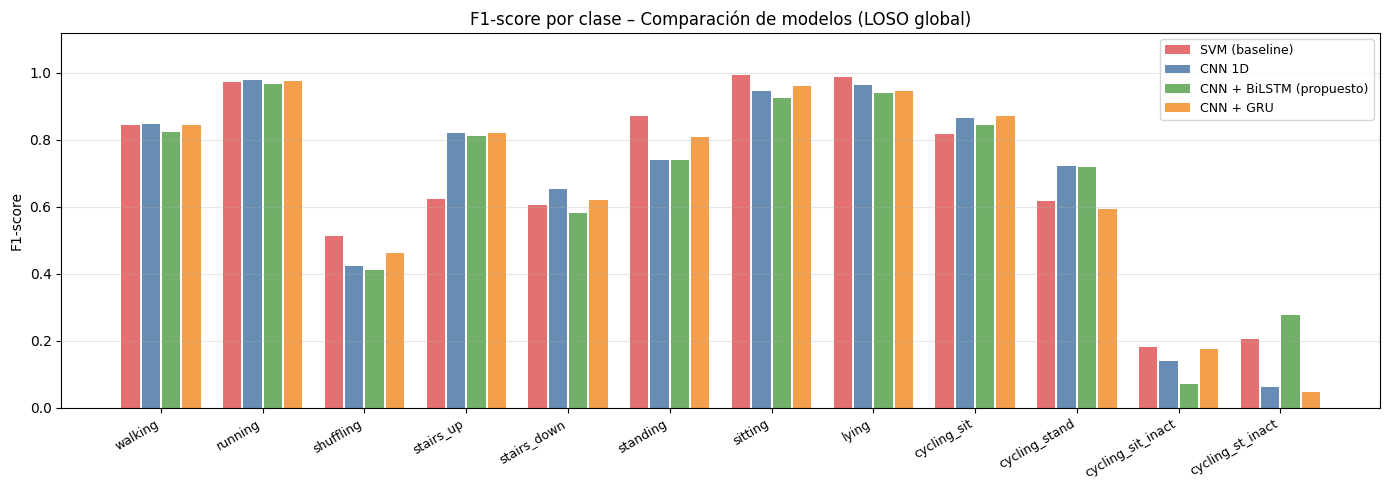

In [18]:
class_names = [IDX_TO_LABEL[i] for i in range(N_CLASSES)]
x = np.arange(N_CLASSES)
n_models = len(all_results)
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(14, 5))
for k, (key, res) in enumerate(all_results.items()):
    f1pc   = res['global_metrics']['f1_per_class']
    offset = (k - n_models/2 + 0.5) * width
    ax.bar(x + offset, f1pc, width * 0.9,
           label=MODEL_LABELS[key], color=MODEL_COLORS[key], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.12)
ax.set_title('F1-score por clase – Comparación de modelos (LOSO global)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150)
plt.show()

---
## CELDA 19 – Gráfico radar de métricas globales

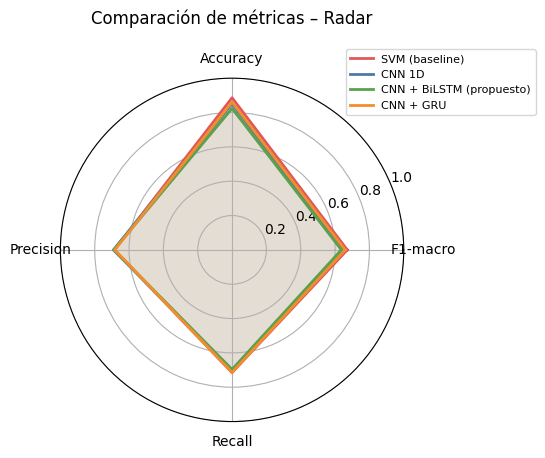

In [19]:
metric_keys   = ['mean_f1_macro', 'mean_accuracy', 'mean_precision', 'mean_recall']
metric_labels = ['F1-macro', 'Accuracy', 'Precision', 'Recall']
n_m = len(metric_keys)
angles = np.linspace(0, 2*np.pi, n_m, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for key, res in all_results.items():
    vals = [res.get(k, 0) for k in metric_keys] + [res.get(metric_keys[0], 0)]
    ax.plot(angles, vals, label=MODEL_LABELS[key],
            color=MODEL_COLORS[key], linewidth=2)
    ax.fill(angles, vals, alpha=0.07, color=MODEL_COLORS[key])

ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels)
ax.set_ylim(0, 1)
ax.set_title('Comparación de métricas – Radar', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig('radar_metrics.png', dpi=150)
plt.show()

---
## CELDA 20 – Guardar todos los resultados en JSON

In [20]:
# Serializar resultados a JSON (por si quieres retomar sin re-entrenar)
import json

for key, res in all_results.items():
    fname = f'results_{key}.json'
    # Convertir arrays numpy a listas para serialización
    def convert(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        raise TypeError
    with open(fname, 'w') as f:
        json.dump(res, f, indent=2, default=convert)
    print(f'  ✅ Guardado: {fname}')

print('\nArchivos generados en esta sesión:')
for fname in ['comparison_table.csv', 'f1_boxplot.png', 'confusion_matrix.png',
              'f1_per_class.png', 'radar_metrics.png',
              'results_svm.json', 'results_cnn1d.json',
              'results_cnn_bilstm.json', 'results_cnn_gru.json']:
    exists = '✅' if Path(fname).exists() else '❌'
    print(f'  {exists} {fname}')

  ✅ Guardado: results_svm.json
  ✅ Guardado: results_cnn1d.json
  ✅ Guardado: results_cnn_bilstm.json
  ✅ Guardado: results_cnn_gru.json

Archivos generados en esta sesión:
  ✅ comparison_table.csv
  ✅ f1_boxplot.png
  ✅ confusion_matrix.png
  ✅ f1_per_class.png
  ✅ radar_metrics.png
  ✅ results_svm.json
  ✅ results_cnn1d.json
  ✅ results_cnn_bilstm.json
  ✅ results_cnn_gru.json
